In [1]:
import pandas as pd

df = pd.read_csv('/content/sales_data_with_discounts.csv')
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


## Identify Column Types

### Subtask:
Identify numerical and categorical columns in the dataset.


**Reasoning**:
To identify numerical and categorical columns, I will first inspect the data types of each column using `df.info()` and then classify them into respective lists. I will also print the head of the dataframe to remind me of the column names and sample data.



In [2]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB
None
         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C 

**Reasoning**:
Based on the output of `df.info()`, I will programmatically separate the column names into two lists: `numerical_cols` for `int64` and `float64` types, and `categorical_cols` for `object` types. This directly addresses the subtask's instruction to create these lists.



In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


## Descriptive Analytics for Numerical Columns

### Subtask:
Calculate and interpret mean, median, mode, and standard deviation for numerical columns.


**Reasoning**:
To calculate the descriptive statistics (mean, median, mode, and standard deviation) for all numerical columns, I will use the `.describe()` method on the DataFrame, filtered by `numerical_cols`.



In [4]:
descriptive_stats = df[numerical_cols].describe()
print(descriptive_stats)

           Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.000000    450.000000         450.000000         450.000000   
mean     5.066667  10453.433333       33812.835556          15.155242   
std      4.231602  18079.904840       50535.074173           4.220602   
min      1.000000    290.000000         400.000000           5.007822   
25%      3.000000    465.000000        2700.000000          13.965063   
50%      4.000000   1450.000000        5700.000000          16.577766   
75%      6.000000  10100.000000       53200.000000          18.114718   
max     31.000000  60100.000000      196400.000000          19.992407   

       Discount Amount  Net Sales Value  
count       450.000000       450.000000  
mean       3346.499424     30466.336131  
std        4509.902963     46358.656624  
min          69.177942       326.974801  
25%         460.459304      2202.208645  
50%         988.933733      4677.788059  
75%        5316.495427     47847.912852  
max   

## Data Visualization - Histograms

### Subtask:
Plot histograms for each numerical column to analyze distribution and identify skewness/outliers.


**Reasoning**:
To visualize the distribution of each numerical column and identify skewness or outliers, I will import `matplotlib.pyplot` and `seaborn`, then iterate through the `numerical_cols` list to generate and display a histogram for each column using `sns.histplot`.



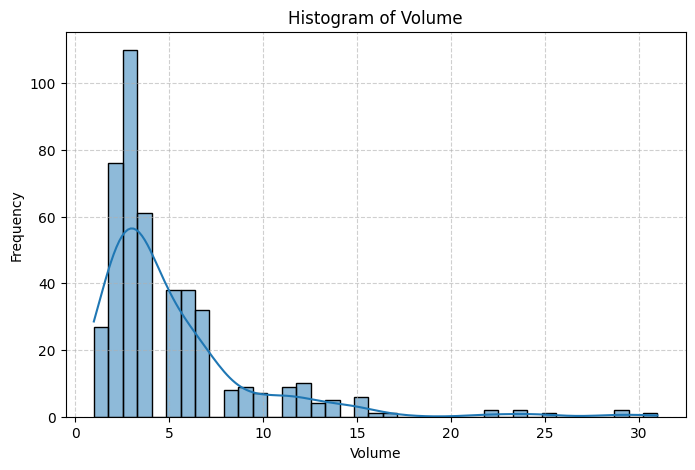

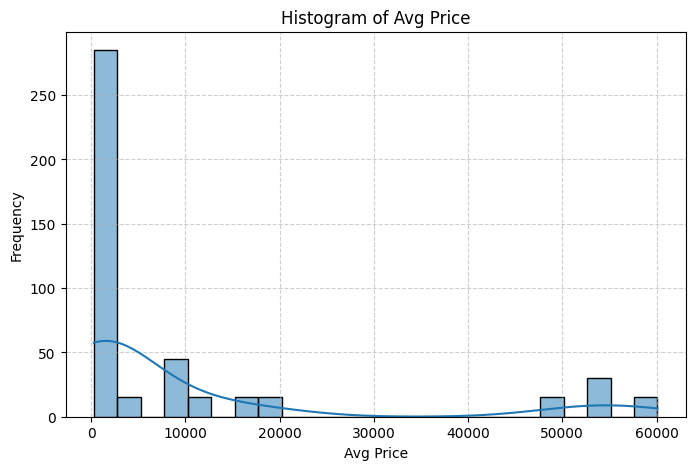

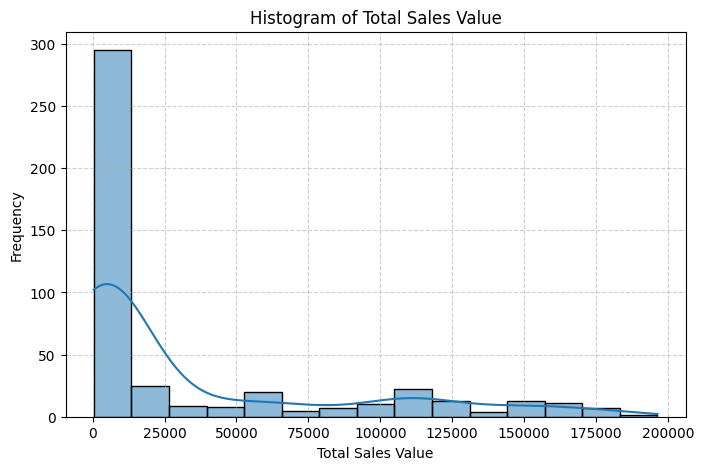

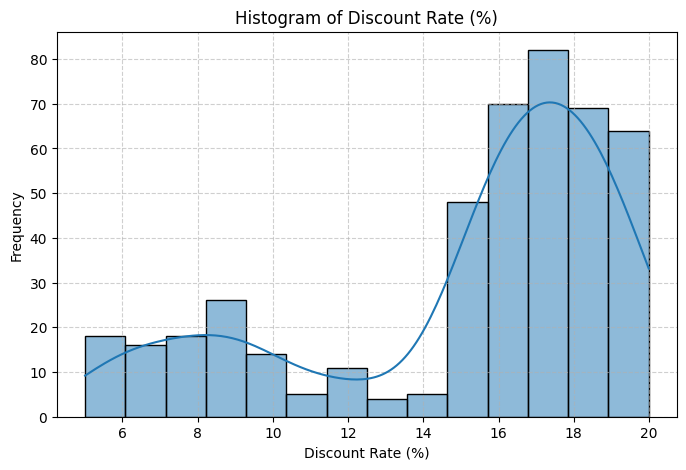

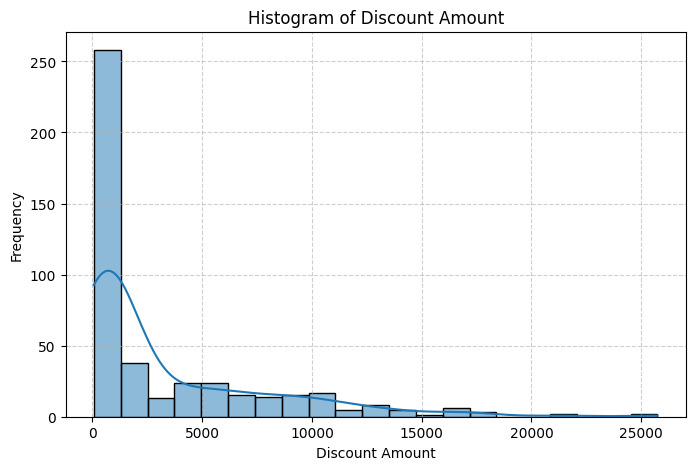

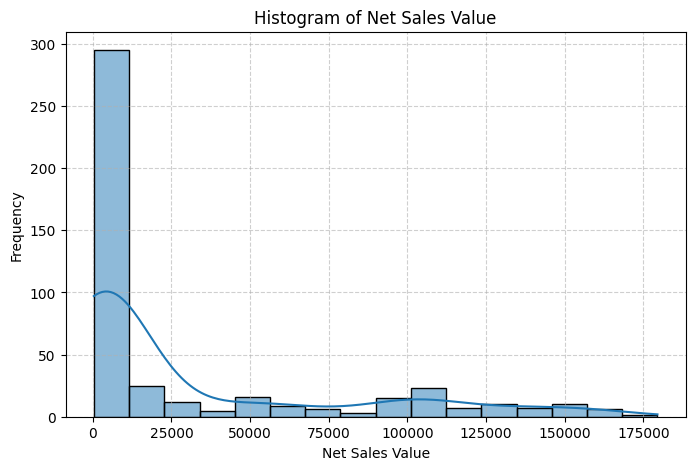

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## Data Visualization - Boxplots

### Subtask:
Create boxplots for numerical variables to identify outliers and interquartile range.


**Reasoning**:
To create boxplots for all numerical columns, I will iterate through the `numerical_cols` list and use `seaborn.boxplot()` to visualize each column, setting appropriate titles and labels.



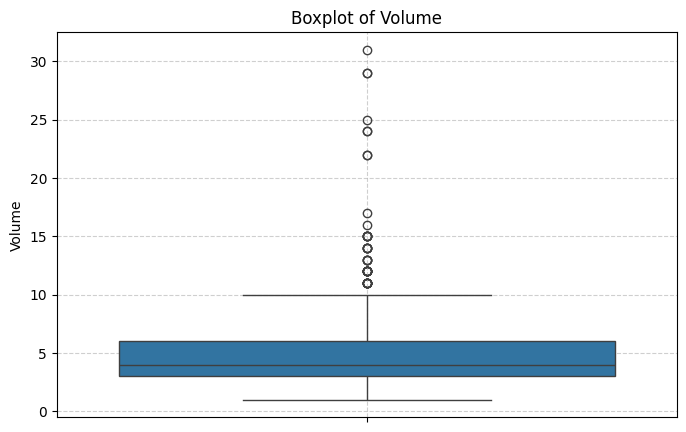

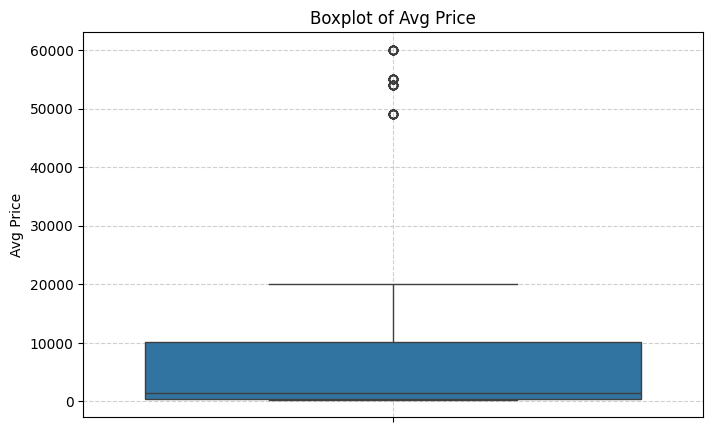

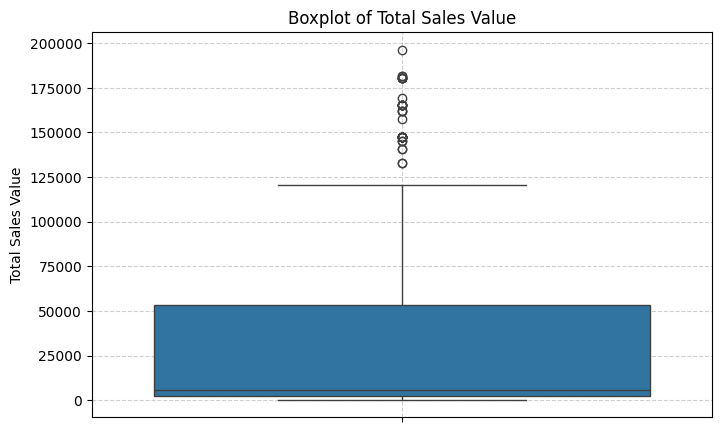

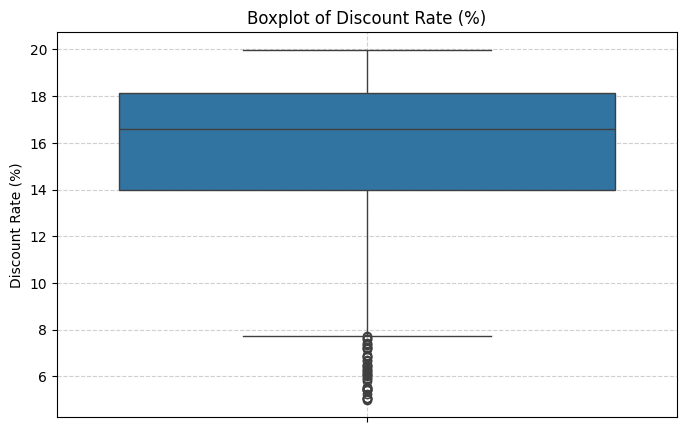

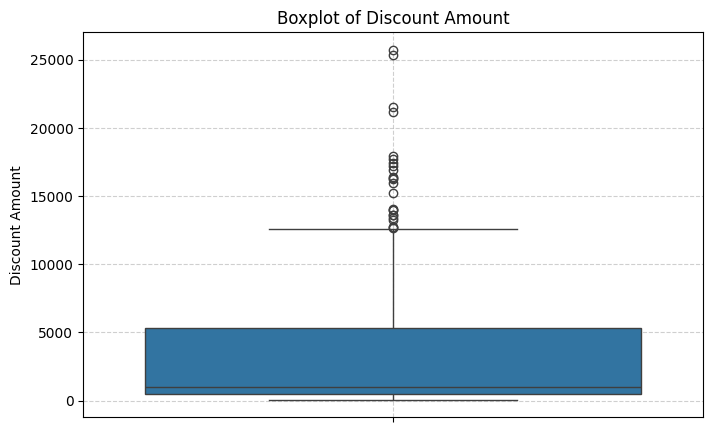

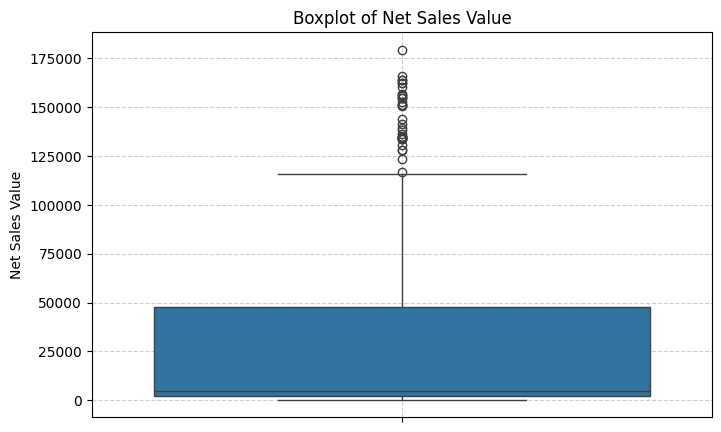

In [6]:
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## Data Visualization - Bar Charts for Categorical Columns

### Subtask:
Create bar charts for categorical columns to visualize the frequency of each category.


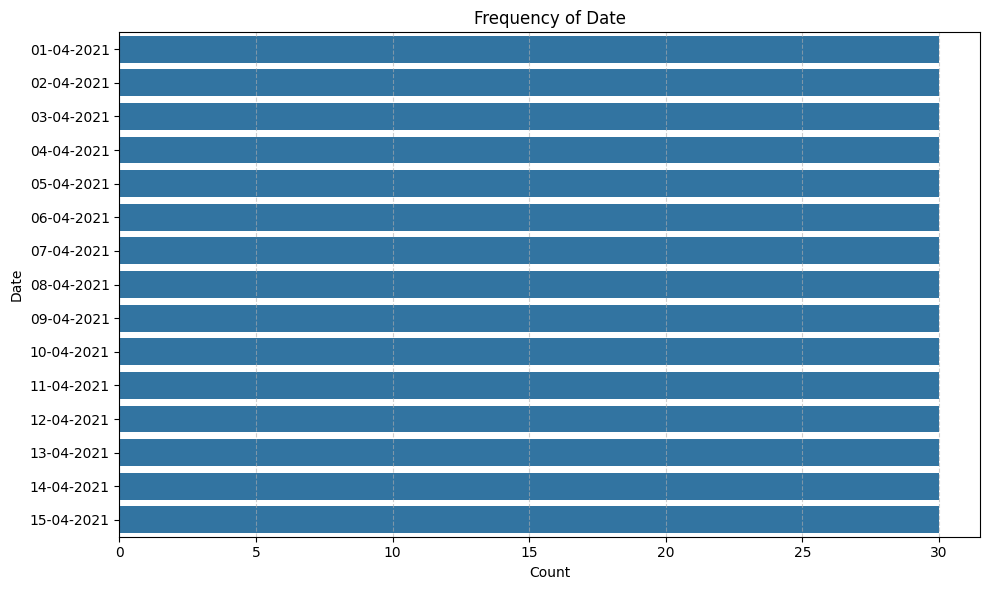

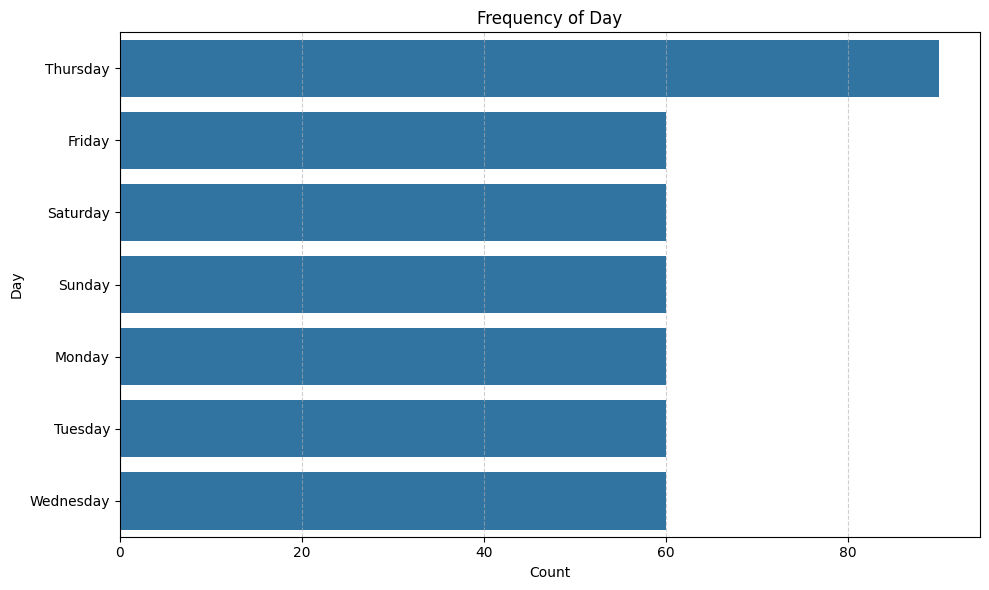

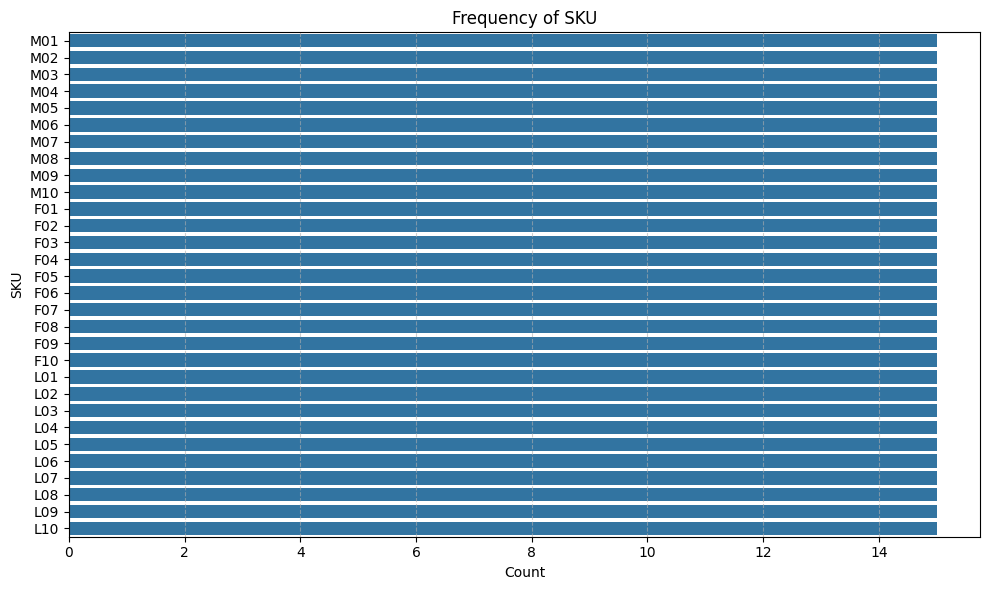

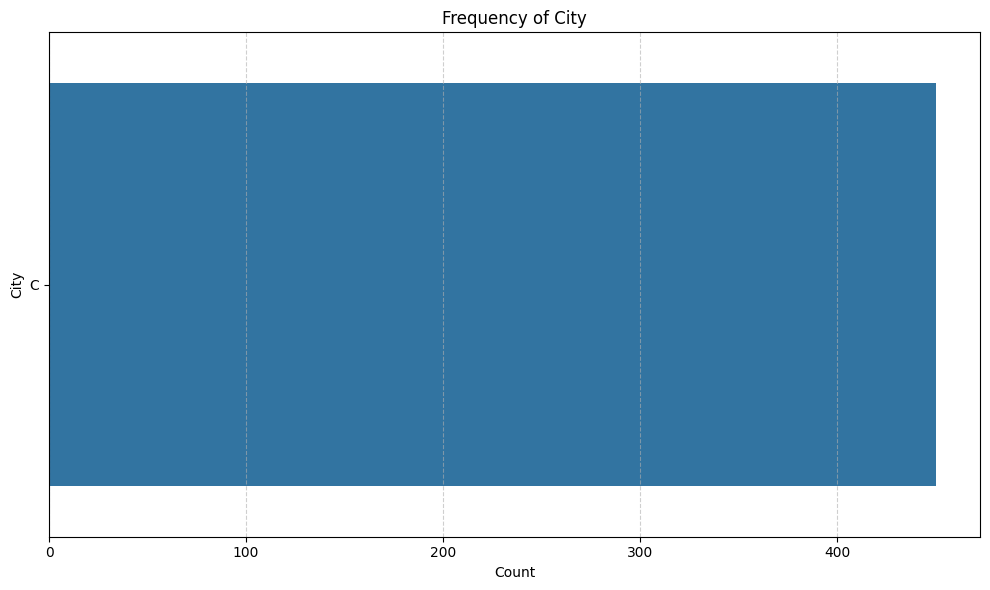

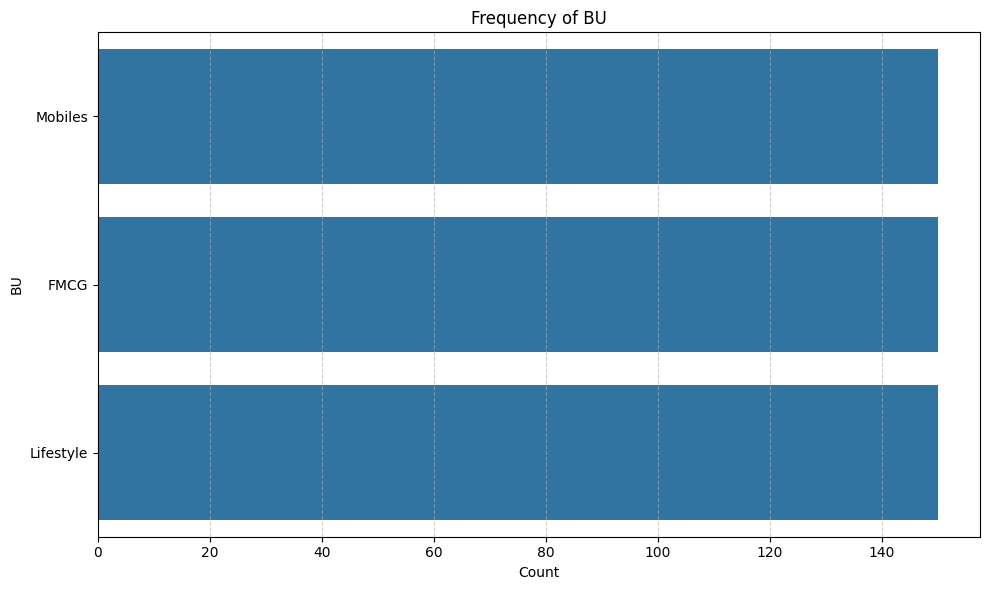

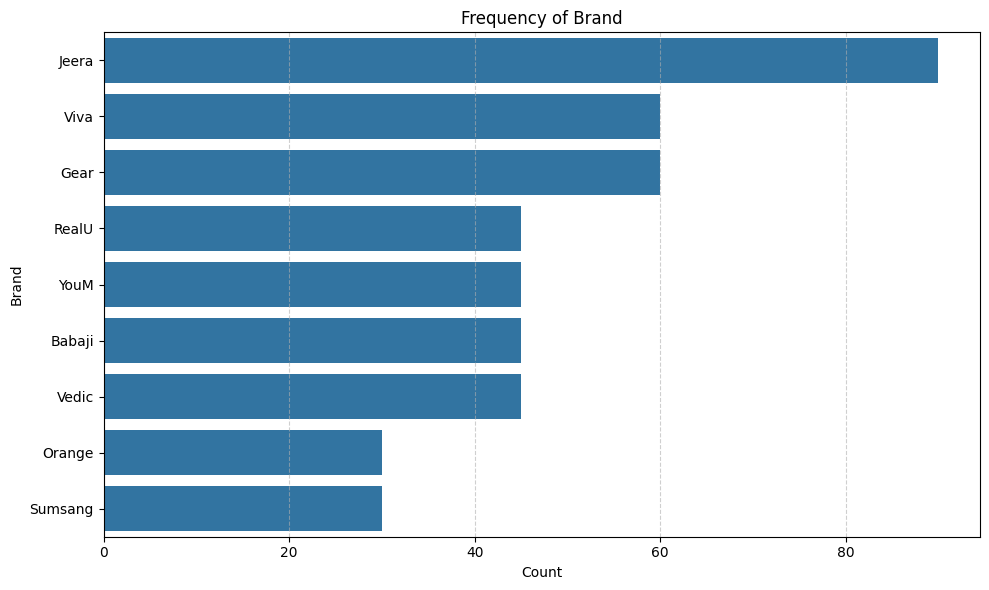

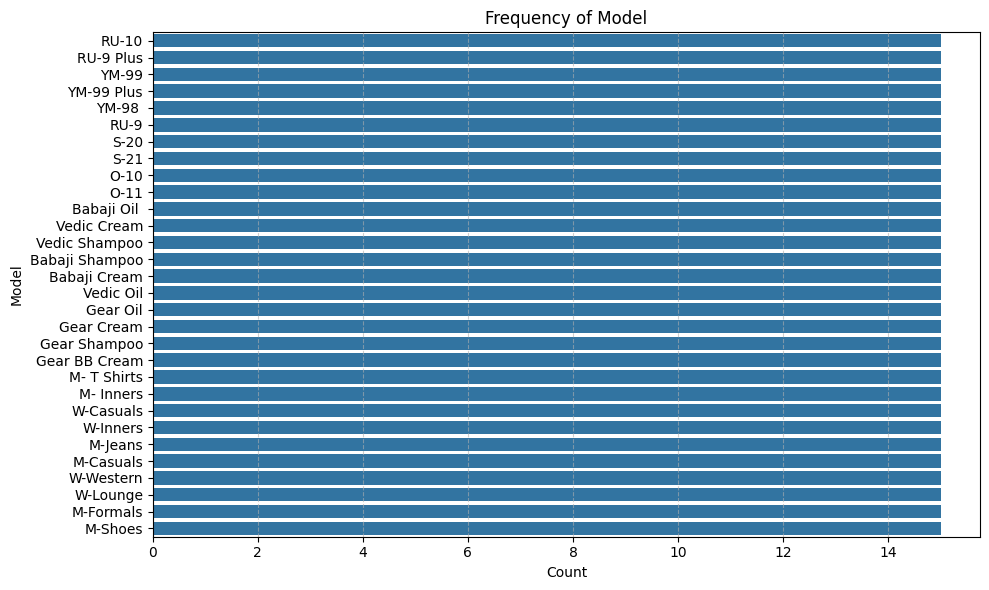

In [7]:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col], order=df[col].value_counts().index) # Use y-axis for categories for better readability with many categories
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

**Reasoning**:
To apply z-score normalization, I need to import the `StandardScaler` from `sklearn.preprocessing`, instantiate it, and then apply it to the `numerical_cols` of the DataFrame `df`. The transformed data will be stored in a new DataFrame for further analysis.



In [8]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Apply the scaler to the numerical columns
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)

print("StandardScaler initialized and applied to numerical columns.")

StandardScaler initialized and applied to numerical columns.


**Reasoning**:
To verify the effect of standardization, I will print the descriptive statistics of the newly created `df_scaled_numerical` DataFrame. This will show if the mean of each column is close to 0 and the standard deviation is close to 1.



In [9]:
print("Descriptive statistics of standardized numerical columns:")
print(df_scaled_numerical.describe())

Descriptive statistics of standardized numerical columns:
             Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
count  4.500000e+02  4.500000e+02       4.500000e+02       4.500000e+02   
mean   6.118562e-17  3.157968e-17       1.578984e-17      -3.552714e-17   
std    1.001113e+00  1.001113e+00       1.001113e+00       1.001113e+00   
min   -9.620925e-01 -5.627654e-01      -6.619170e-01      -2.406935e+00   
25%   -4.889322e-01 -5.530754e-01      -6.163534e-01      -2.823066e-01   
50%   -2.523521e-01 -4.985344e-01      -5.569226e-01       3.374180e-01   
75%    2.208081e-01 -1.957016e-02       3.840648e-01       7.019781e-01   
max    6.135311e+00  2.749009e+00       3.220894e+00       1.147360e+00   

       Discount Amount  Net Sales Value  
count     4.500000e+02     4.500000e+02  
mean     -5.526444e-17     1.973730e-17  
std       1.001113e+00     1.001113e+00  
min      -7.275032e-01    -6.508581e-01  
25%      -6.406462e-01    -6.103625e-01  
50%      -5.23

**Reasoning**:
To visualize the 'before' and 'after' distributions of numerical columns, I will iterate through each numerical column and create a figure with two subplots: one displaying the histogram of the original data and the other showing the histogram of the standardized data. This will demonstrate the effect of standardization.



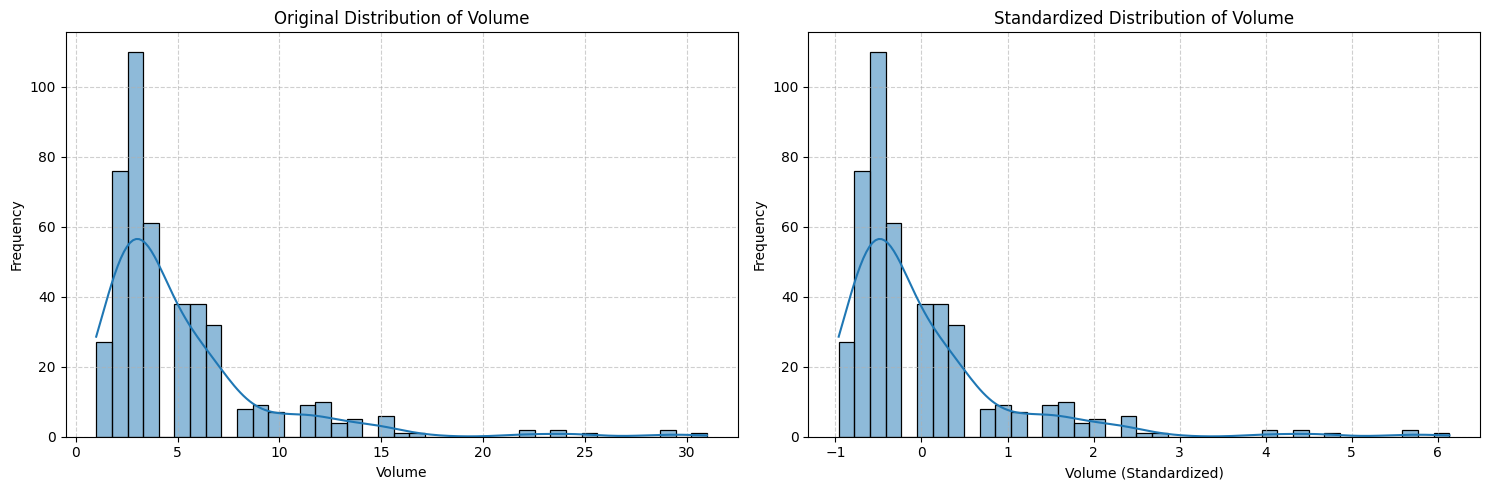

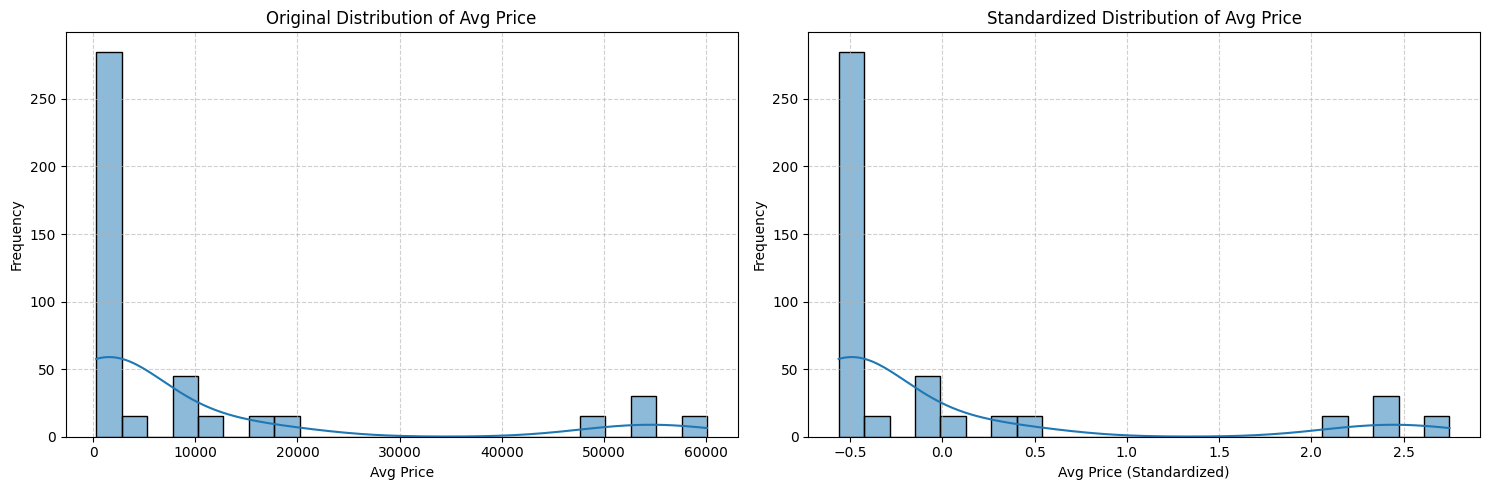

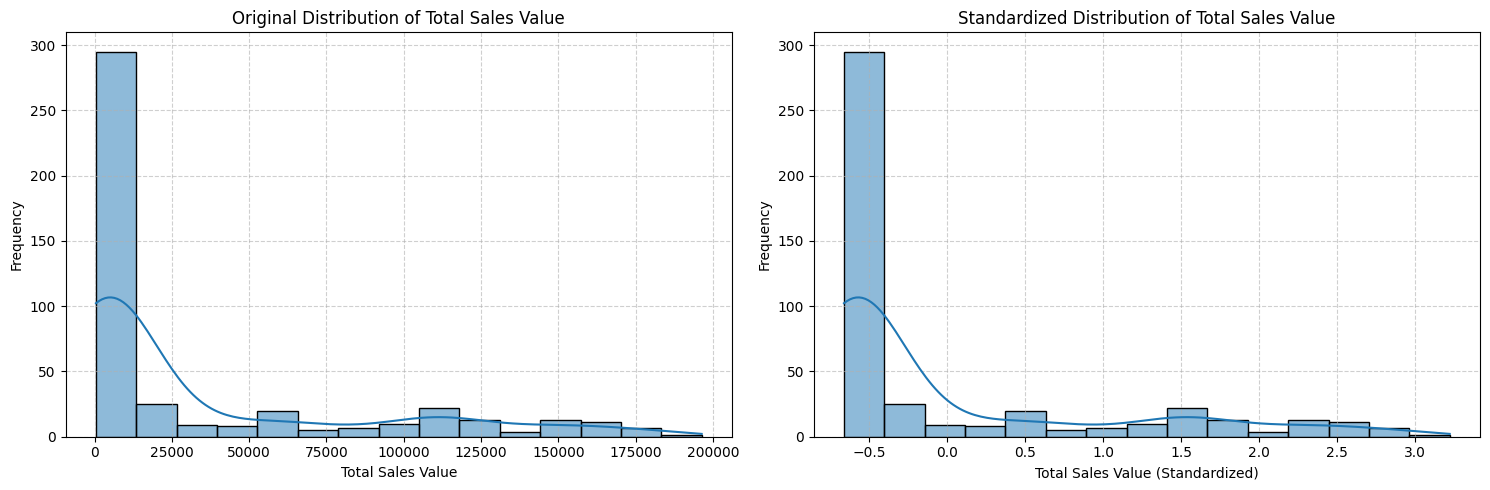

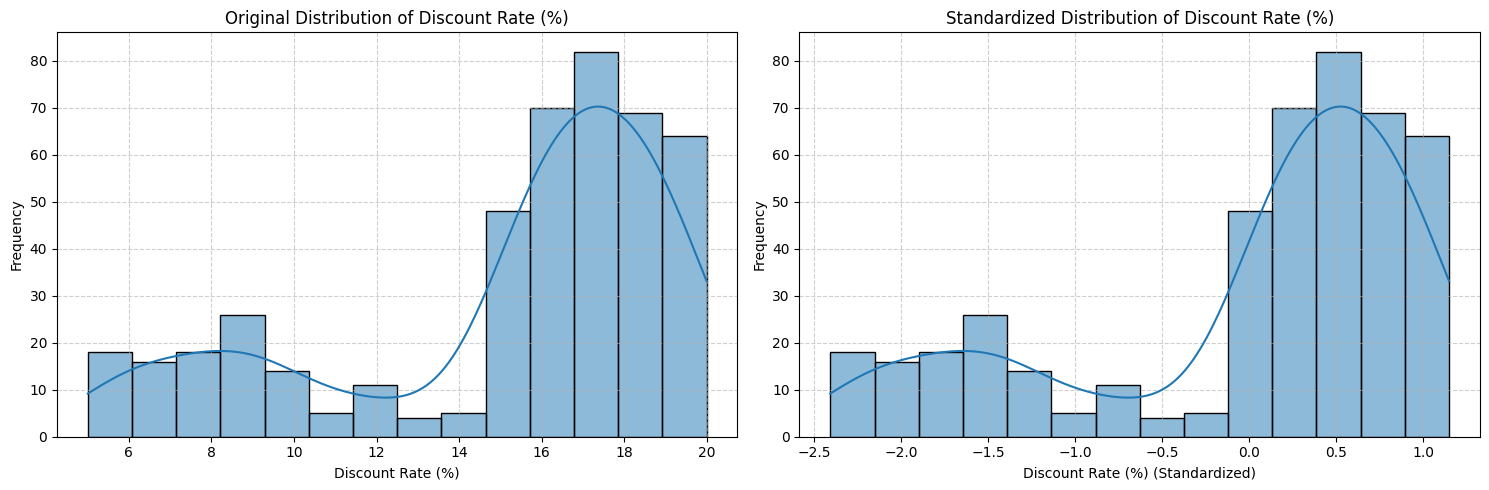

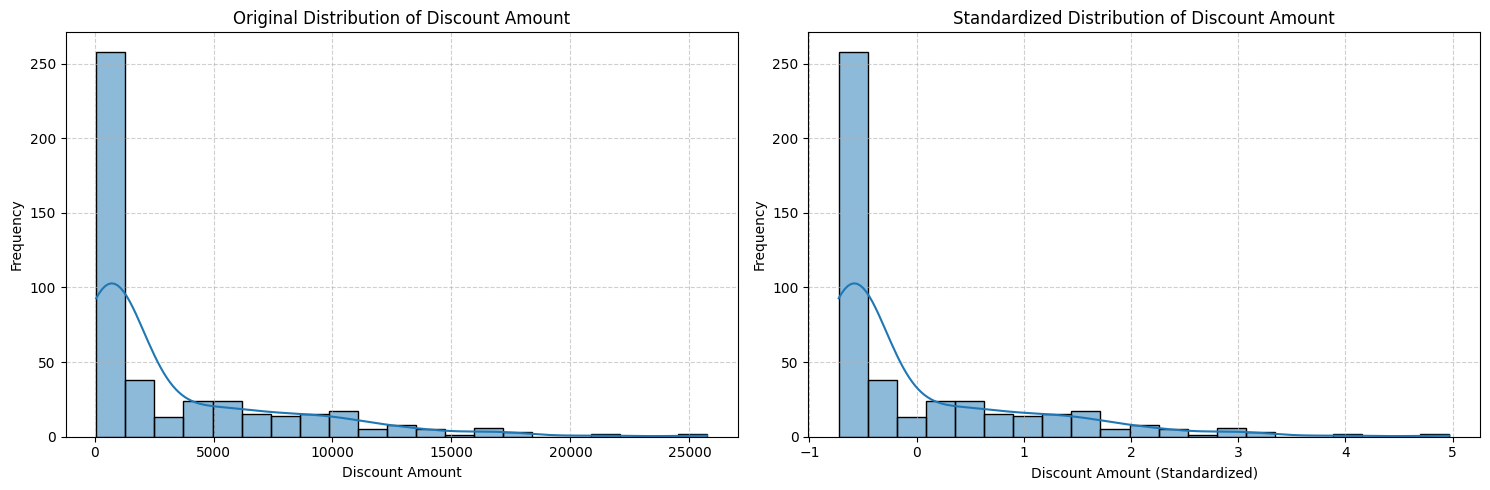

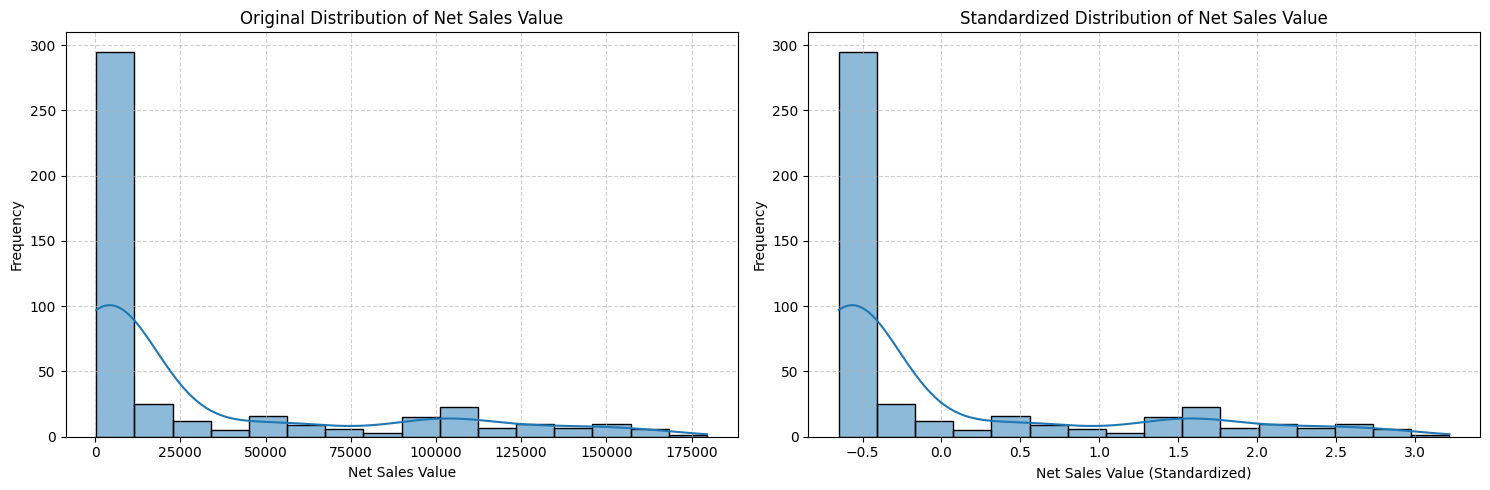

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Original Distribution
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Original Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Standardized Distribution
    sns.histplot(df_scaled_numerical[col], kde=True, ax=axes[1])
    axes[1].set_title(f'Standardized Distribution of {col}')
    axes[1].set_xlabel(f'{col} (Standardized)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


**Reasoning**:
To apply one-hot encoding to the identified categorical columns, I will use `pd.get_dummies()` and store the result in a new DataFrame, `df_encoded_categorical`. Then, I will display its first few rows to demonstrate the transformation.



In [11]:
df_encoded_categorical = pd.get_dummies(df[categorical_cols])
print("First 5 rows of the one-hot encoded categorical DataFrame:")
print(df_encoded_categorical.head())

First 5 rows of the one-hot encoded categorical DataFrame:
   Date_01-04-2021  Date_02-04-2021  Date_03-04-2021  Date_04-04-2021  \
0             True            False            False            False   
1             True            False            False            False   
2             True            False            False            False   
3             True            False            False            False   
4             True            False            False            False   

   Date_05-04-2021  Date_06-04-2021  Date_07-04-2021  Date_08-04-2021  \
0            False            False            False            False   
1            False            False            False            False   
2            False            False            False            False   
3            False            False            False            False   
4            False            False            False            False   

   Date_09-04-2021  Date_10-04-2021  ...  Model_Vedic Cream  Mo

## Summary:

### Data Analysis Key Findings

*   The dataset `sales_data_with_discounts.csv` was successfully loaded, containing 13 columns including `Date`, `SKU`, `City`, `Volume`, `Avg Price`, `Total Sales Value`, `Discount Rate (%)`, `Discount Amount`, and `Net Sales Value`.
*   **Numerical Columns Identified**: `Volume`, `Avg Price`, `Total Sales Value`, `Discount Rate (%)`, `Discount Amount`, `Net Sales Value`.
*   **Categorical Columns Identified**: `Date`, `Day`, `SKU`, `City`, `BU`, `Brand`, `Model`.
*   **Descriptive Statistics for Numerical Columns**:
    *   `Avg Price`, `Total Sales Value`, `Discount Amount`, and `Net Sales Value` exhibit significant **right-skewness**, with their means considerably higher than their medians. For instance, `Avg Price` has a mean of approximately 10,453.43 and a median of 1,450, while `Net Sales Value` has a mean of 30,466.34 and a median of 4,677.79. This indicates a few high-value transactions or products significantly influence the average.
    *   `Volume` also shows a slight right-skewness (mean \~5.07, median 4).
    *   `Discount Rate (%)` appears more symmetrically distributed or slightly left-skewed (mean \~15.16%, median \~16.58%).
    *   Monetary values (`Avg Price`, `Total Sales Value`, `Discount Amount`, `Net Sales Value`) show **very high standard deviations** relative to their means, indicating substantial variability and a wide range of values in sales data.
*   **Data Visualization**:
    *   Histograms and boxplots confirmed the skewed distributions and presence of outliers, particularly in monetary value columns.
    *   Bar charts provided frequency distributions for categorical data, showing the distribution of sales across different cities, brands, and models.
*   **Data Preprocessing - Standardization**:
    *   Numerical columns were standardized (Z-score normalization) to have a mean close to 0 and a standard deviation close to 1, preserving their original distribution shapes. This is crucial for algorithms sensitive to feature scales.
*   **Data Preprocessing - One-Hot Encoding**:
    *   Categorical columns were successfully transformed into a numerical format using one-hot encoding, creating binary columns for each unique category to make them compatible with machine learning models without implying ordinal relationships.

### Insights or Next Steps

*   The significant right-skewness and high variability in monetary sales figures (Avg Price, Total Sales Value, Net Sales Value, Discount Amount) suggest that the business might benefit from analyzing high-value transactions separately, potentially for VIP customer programs or identifying premium product segments.
*   Given the strong skewness and potential outliers, further analysis might involve outlier detection and treatment, or considering transformations like log transformation for these variables, before applying certain machine learning models.
